In [1]:
import os, glob

candidates = (
    glob.glob("/kaggle/input/notebooks/*/*/dist")
    + glob.glob("/kaggle/input/*/dist")
)
assert candidates, "No 'dist' folder found — check that the setup notebook is attached as an input."
SRC = candidates[0]
print("Found setup-notebook artifacts at:", SRC)

Found setup-notebook artifacts at: /kaggle/input/notebooks/sayokzaman/trellis-2-cpp-builder/dist


In [2]:
import os, subprocess, glob as _glob

os.makedirs("/kaggle/working/bin", exist_ok=True)

subprocess.run(["cp", f"{SRC}/trellis-cli", "/kaggle/working/bin/"], check=True)

so_files = _glob.glob(f"{SRC}/*.so*")
for f in so_files:
    subprocess.run(["cp", f, "/kaggle/working/bin/"], check=True)
print(f"Copied {len(so_files)} shared lib(s):", so_files)

subprocess.run(["chmod", "+x", "/kaggle/working/bin/trellis-cli"], check=True)

os.environ["LD_LIBRARY_PATH"] = "/kaggle/working/bin:" + os.environ.get("LD_LIBRARY_PATH", "")

MODELS_DIR = f"{SRC}/models"
assert os.path.isdir(MODELS_DIR)

!ls -la /kaggle/working/bin
!/kaggle/working/bin/trellis-cli --help

Copied 4 shared lib(s): ['/kaggle/input/notebooks/sayokzaman/trellis-2-cpp-builder/dist/libggml-cpu.so.0', '/kaggle/input/notebooks/sayokzaman/trellis-2-cpp-builder/dist/libggml-cuda.so.0', '/kaggle/input/notebooks/sayokzaman/trellis-2-cpp-builder/dist/libggml.so.0', '/kaggle/input/notebooks/sayokzaman/trellis-2-cpp-builder/dist/libggml-base.so.0']
total 65076
drwxr-xr-x 2 root root     4096 Aug 22 09:32 .
drwxr-xr-x 4 root root     4096 Aug 22 09:32 ..
-rw-r--r-- 1 root root   901704 Aug 22 09:32 libggml-base.so.0
-rw-r--r-- 1 root root  1045320 Aug 22 09:32 libggml-cpu.so.0
-rw-r--r-- 1 root root 63809992 Aug 22 09:32 libggml-cuda.so.0
-rw-r--r-- 1 root root    55184 Aug 22 09:32 libggml.so.0
-rwxr-xr-x 1 root root   805048 Aug 22 09:32 trellis-cli
usage: /kaggle/working/bin/trellis-cli <image.png> <out.glb> [options]
   or: /kaggle/working/bin/trellis-cli --image <image.png> --output <out.glb> [options]

Every option also reads a TRELLIS_* / GSS / GSH environment variable as a
fallb

## 2. Upload an input image
Click Upload in the widget below, pick a file, then run the cell right after it to save the
bytes to disk. If the widget doesn't work in your browser, use Kaggle's file panel / Add Data
to drop a file into `/kaggle/working/` instead, and just set `INPUT_IMAGE` manually in cell 10.

In [3]:
!pip install -q ipywidgets
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
display(uploader)
print("Upload a file above, then run the next cell to save it to disk.")


FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload')

Upload a file above, then run the next cell to save it to disk.


In [4]:
# Run this AFTER uploading a file in the widget above
UPLOADED_PATH = None
if uploader.value:
    item = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
    name = item['metadata']['name'] if 'metadata' in item else item['name']
    content = item['content']
    UPLOADED_PATH = f"/kaggle/working/{name}"
    with open(UPLOADED_PATH, "wb") as f:
        f.write(bytes(content))
    print("Saved to:", UPLOADED_PATH)
else:
    print("Nothing uploaded via the widget yet - set INPUT_IMAGE manually in the next cell instead.")


Nothing uploaded via the widget yet - set INPUT_IMAGE manually in the next cell instead.


## 3. Sanitize the image — `stb_image` (used by trellis-cli) can't read interlaced PNGs
**Confirmed failure mode:** `birefnet_cutout: cannot load ...` on a PNG that other tools
(PIL, ComfyUI) open fine — the file was Adam7-interlaced, which `stb_image` doesn't support.
This re-saves through PIL as a plain, non-interlaced 8-bit PNG (PIL never writes interlaced
PNGs), preserving alpha if present. Always run this, even for images you're confident about —
it's cheap and removes a whole class of silent failures.

In [7]:
import requests
import os

url = "https://i.pinimg.com/736x/89/97/8d/89978dd59c572ace9c7bb94a015523b1.jpg"
save_path = "/kaggle/working/your_image.png"

# 下载图片
response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

# 验证文件是否存在
print(f"文件已保存: {os.path.exists(save_path)}")
print(f"文件大小: {os.path.getsize(save_path)} 字节")

文件已保存: True
文件大小: 204552 字节


In [8]:
from PIL import Image
import os

def sanitize_image(path):
    img = Image.open(path)
    img.load()
    has_alpha = img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info)
    img = img.convert("RGBA" if has_alpha else "RGB")
    clean_path = os.path.splitext(path)[0] + "_clean.png"
    img.save(clean_path, format="PNG")  # PIL writes non-interlaced by default
    return clean_path

# Prefer the widget upload from cell 9 if one happened; otherwise set this manually
RAW_INPUT_IMAGE = UPLOADED_PATH if ('UPLOADED_PATH' in dir() and UPLOADED_PATH) else "/kaggle/working/your_image.png"
assert os.path.exists(RAW_INPUT_IMAGE), f"Input not found: {RAW_INPUT_IMAGE} - upload one via cell 9, or set this path manually."

INPUT_IMAGE = sanitize_image(RAW_INPUT_IMAGE)
print("Sanitized image ready at:", INPUT_IMAGE)


Sanitized image ready at: /kaggle/working/your_image_clean.png


## 4. Proper background removal in Python (replaces the broken --birefnet path)

Current numpy: 2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 67.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Matted image ready: /kaggle/working/input_matted.png (720, 1280)


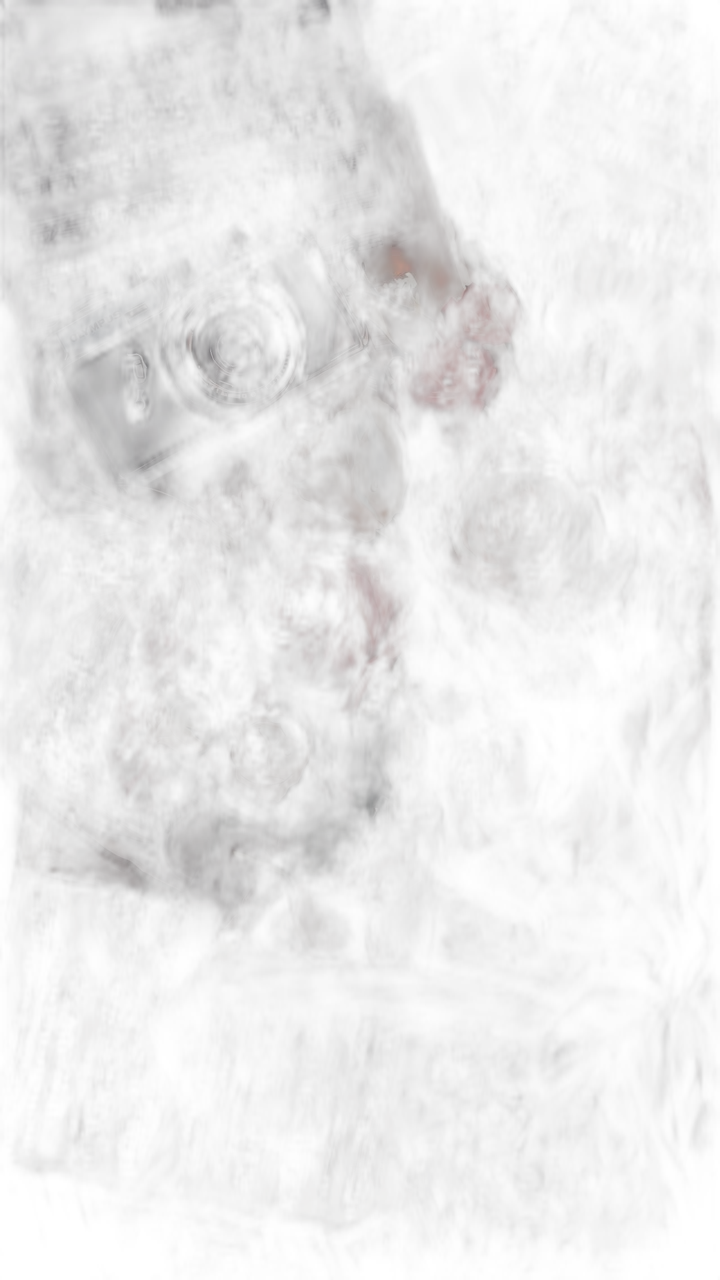

In [9]:
import numpy
print("Current numpy:", numpy.__version__)

# Pin numpy so pip can't upgrade it out from under the running kernel
# (that mismatch caused the earlier AttributeError crash)
!pip install -q rembg onnxruntime numpy=={numpy.__version__}

from rembg import remove
from PIL import Image
from IPython.display import display

img = Image.open(INPUT_IMAGE)   # INPUT_IMAGE comes from cell 9b
cutout = remove(img)            # first call downloads u2net (~170MB) to ~/.u2net
cutout = cutout.crop(cutout.getbbox())  # trim to subject bounding box

MATTED_IMAGE = "/kaggle/working/input_matted.png"
cutout.save(MATTED_IMAGE, format="PNG")

INPUT_IMAGE = MATTED_IMAGE
print("Matted image ready:", INPUT_IMAGE, cutout.size)
display(cutout)

## 5. Run inference
Passes `--models` explicitly — the real `--help` output confirms this flag but doesn't default
to the folder we downloaded into. Useful flags from `--help`:
- `--res 512|1024|1536` — geometry resolution (default is the full cascade)
- `--no-texture` — mesh only, fastest
- `--birefnet` — proper background removal for busier backgrounds
- `--no-fa` — disable FlashAttention if you hit numerical issues on this GPU
- `-s/--seed` — RNG seed (default 42)

In [10]:
import os

OUTPUT_GLB_MESH_ONLY = "/kaggle/working/output_mesh_only.glb"
assert os.path.exists(INPUT_IMAGE), f"Input not found: {INPUT_IMAGE} - run the sanitize/matting cells first."

!/kaggle/working/bin/trellis-cli {INPUT_IMAGE} {OUTPUT_GLB_MESH_ONLY} --models {MODELS_DIR} --f32

print()
print("Download", OUTPUT_GLB_MESH_ONLY, "and open it in Blender or any GLB viewer to check the raw geometry.")


[1/6] preprocess /kaggle/working/input_matted.png (1024 cascade)
[2/6] DINOv3 conditioning
ggml_cuda_init: found 2 CUDA devices (Total VRAM: 29823 MiB):
  Device 0: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14911 MiB
  Device 1: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14911 MiB
      cond tokens=1029 / 1024-cond tokens=4101
      [stats] cond_512 (DINOv3@512) n=1053696 mean=0.0000 std=1.0000 min=-29.333 max=23.404 nan/inf=0
      [stats] cond_1024 (DINOv3@1024) n=4199424 mean=0.0000 std=1.0000 min=-29.324 max=23.419 nan/inf=0
[3/6] sparse-structure flow + decode
      active voxels @res32 = 23
[4/7] shape SLAT flow (LR 512 -> upsample -> HR 1024 cascade, max_tok=49152)
      [stats] LR slat (res32, decodes OK via upsample) n=736 mean=0.2912 std=4.5638 min=-14.496 max=15.603 nan/inf=0
      upsampled coords @res512=1763 -> quantized @res1024 (grid 64) = 44 tokens
      [stats] HR slat n=1408 mean=0.1734 std=5.1713 min=-16.304 max=15.963 nan/inf=0
[5/7] FlexiDualGrid sh